# Experiment 1: JIT simulations visualization

In [1]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import os
import pickle
import glob 
import itertools
import json
from collections import Counter
import ast
from collections import deque
import matplotlib.cm as cm
from matplotlib import gridspec
import matplotlib.patches as patches
import math
from copy import deepcopy
import pickle
import heapq

import models.mdps as mdps
import models.jit as jit


start_goal_pos = [(8,1),(8,15)]


figpath = os.path.join("fig")
fitspath = os.path.join("modelfits")
data_savepath = os.path.join("data")
datapath = os.path.join("..","experiment","data", "exp1")

# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

def maze_to_char_array(maze):
    return np.array([list(row) for row in maze])

## 0) Load human data

In [2]:

# Load test mazes
with open(os.path.join("data",'test_mazes.pkl'), 'rb') as file:
    test_mazes = pickle.load(file)
    
maze_size = len(test_mazes)

# Could the JIT model capture the intercondition difference?

In [3]:
def location_on_shared_walls(r,c, n_rows, n_cols):
    if(r==1 or r==(n_rows-2)):
        if(c>0 and c<(n_cols-1)):
            return True
    elif(c==1 or c==(n_cols-2)):
        if(r>0 and r<(n_rows-1)):
            return True
    return False
        

def parse_maze_with_numbered_walls(
    maze_arr,
    start=(8,1),
    goal=(8,15),
    wall_start_idx=0,
):
    """
    Convert a maze char array into a labeled object array.

    Parameters
    ----------
    maze_arr : np.ndarray
        2D array from maze_to_char_array(), containing symbols like
        '+', '-', '.', '#'
    start : tuple or None
        (row, col) coordinate to label as 'S'
    goal : tuple or None
        (row, col) coordinate to label as 'G'
    wall_start_idx : int
        Starting integer for numbering '#' cells

    Returns
    -------
    out : np.ndarray
        2D object array of strings, where:
        - '+', '-', '.' become '.'
        - each '#' becomes a unique string integer
        - start becomes 'S'
        - goal becomes 'G'
    """
    maze_arr = np.asarray(maze_arr)
    if maze_arr.ndim != 2:
        raise ValueError(f"maze_arr must be 2D, got shape {maze_arr.shape}")

    n_rows, n_cols = maze_arr.shape
    out = np.empty((n_rows, n_cols), dtype=object)

    wall_counter = wall_start_idx
    
    shared_construal = []

    for r in range(n_rows):
        for c in range(n_cols):
            val = maze_arr[r, c]

            if val in ['+', '-', '.']:
                out[r, c] = '.'
            elif val == '#':
                out[r, c] = str(wall_counter)
                if(location_on_shared_walls(r,c,n_rows,n_cols)): # The shared maze walls across mazes
                    shared_construal.append(wall_counter)
                wall_counter += 1
            else:
                raise ValueError(f"Unexpected maze symbol {val!r} at {(r, c)}")

    # overwrite start / goal after wall numbering
    if start is not None:
        sr, sc = start
        if not (0 <= sr < n_rows and 0 <= sc < n_cols):
            raise ValueError(f"start {start} is out of bounds for maze shape {maze_arr.shape}")
        out[sc, sr] = 'S'

    if goal is not None:
        gr, gc = goal
        if not (0 <= gr < n_rows and 0 <= gc < n_cols):
            raise ValueError(f"goal {goal} is out of bounds for maze shape {maze_arr.shape}")
        out[gc, gr] = 'G'

    return out, shared_construal


def maze_to_char_array(maze):
    return np.array([list(row) for row in maze])


def build_original_maze_bg(maze_arr):
    """
    wall(#) -> 0
    open    -> 1
    """
    bg = np.ones(maze_arr.shape, dtype=float)
    bg[maze_arr == '#'] = 0.0
    return bg


def build_state_occupancy_map(paths, maze_shape, xy_to_rc=True, binary_per_rollout=False):
    """
    Build occupancy map from simulated paths.
    xy_to_rc=True means each path point is (x, y) and should map to occ[y, x].
    """
    occ = np.zeros(maze_shape, dtype=float)

    for path in paths:
        this_occ = np.zeros(maze_shape, dtype=float)

        for pos in path:
            a, b = pos[:2]

            if xy_to_rc:
                x, y = int(a), int(b)
                r, c = y, x
            else:
                r, c = int(a), int(b)

            if 0 <= r < maze_shape[0] and 0 <= c < maze_shape[1]:
                if binary_per_rollout:
                    this_occ[r, c] = 1
                else:
                    this_occ[r, c] += 1

        occ += this_occ

    return occ


def build_obstacle_prob_map(parsed_maze, probs):
    """
    Map probs[j] onto numbered wall cells labeled 'j+1' in parsed_maze.
    Non-wall cells are NaN.
    """
    n_rows, n_cols = parsed_maze.shape
    prob_map = np.full((n_rows, n_cols), np.nan, dtype=float)

    for r in range(n_rows):
        for c in range(n_cols):
            val = parsed_maze[r, c]
            if isinstance(val, str) and val.isdigit():
                idx = int(val) 
                if 0 <= idx < len(probs):
                    prob_map[r, c] = probs[idx]

    return prob_map


def run_jit_on_single_maze(
    test_maze,
    start_goal_pos,
    pars,
    n_sims=100,
    seed=45,
    xy_to_rc=True,
    binary_per_rollout=False,
    maze_size = 16,
    verbose=False,
):
    """
    Run JIT rollout repeatedly on one maze.

    Parameters
    ----------
    test_maze : maze in original string-list format
    start_goal_pos : tuple/list like [(start_row, start_col), (goal_row, goal_col)]
    pars : jit.AStarPars
    n_sims : int
    seed : int
    xy_to_rc : bool
        For occupancy map construction.
    binary_per_rollout : bool
        If True, occupancy counts unique visited cells per rollout.
    verbose : bool

    Returns
    -------
    result : dict with keys
        maze_arr
        parsed_maze
        g
        paths
        construals
        probs
        occ
        prob_map
    """
    maze_arr = maze_to_char_array(test_maze)
    parsed_maze, init_construal = parse_maze_with_numbered_walls(
        maze_arr,
        start=start_goal_pos[0],
        goal=start_goal_pos[1]
    )

    g = mdps.GridWorld.from_string(parsed_maze)

    probs = np.zeros(len(g.obstacles), dtype=float)
    paths = []
    construals = []

    random.seed(seed)

    for i in range(n_sims):
        if verbose:
            print(f"sim {i}")

        # Their y-axis is flipped relative to mine, so start at (8,15), goal at (8,1)
        path, construal, data = jit.AStarRolloutStraight.construe_one(
            (start_goal_pos[0][0], maze_size-start_goal_pos[0][1]),   # rollout start in JIT notation
            (start_goal_pos[1][0], maze_size-start_goal_pos[1][1]),   # rollout goal in JIT notation
            g,
            set(),
            pars
        )

        paths.append(path)
        construals.append(construal)

        for j, v in enumerate(data[-1]["construal_traces"]):
            probs[j] += v / n_sims

    # Convert to my notation---start from (8,1), end at (8,15)
    paths = [[(tup[0],maze_size-tup[1]) for tup in path] for path in paths]
    
    occ = build_state_occupancy_map(
        paths,
        maze_shape=maze_arr.shape,
        xy_to_rc=xy_to_rc,
        binary_per_rollout=binary_per_rollout
    )

    prob_map = build_obstacle_prob_map(parsed_maze, probs)

    return {
        "maze_arr": maze_arr,
        "parsed_maze": parsed_maze,
        "g": g,
        "paths": paths,
        "construals": construals,
        "probs": probs,
        "occ": occ,
        "prob_map": prob_map,
    }


def run_jit_across_mazes_and_plot(
    test_mazes,
    start_goal_pos,
    pars,
    n_sims=10,
    seed=0,
    xy_to_rc=True,
    binary_per_rollout=False,
    figsize_per_maze=(4.5, 4.5),
    shared_colorbars=True,
    verbose=False,
    plot_figure=False,
):
    """
    Run JIT on all mazes and create a 3 x n_mazes panel.

    Rows:
      0 -> raw maze
      1 -> state occupancy heatmap
      2 -> obstacle probability heatmap

    Parameters
    ----------
    test_mazes : list
        List of mazes in original string-list format
    start_goal_pos : tuple/list
        [(start_row, start_col), (goal_row, goal_col)]
    pars : jit.AStarPars
    n_sims : int
    seed : int
    xy_to_rc : bool
    binary_per_rollout : bool
    figsize_per_maze : tuple
        (width_per_col, height_per_row-ish scaling)
    shared_colorbars : bool
        If True, share scales across mazes for occupancy and prob maps
    verbose : bool

    Returns
    -------
    fig, ax, results
        results is a list of dicts, one per maze
    """
    n_mazes = len(test_mazes)
    results = []

    # -------------------------
    # Run all mazes first
    # -------------------------
    for maze_idx, test_maze in enumerate(test_mazes):
        if verbose:
            print(f"Running maze {maze_idx}/{n_mazes - 1}")

        result = run_jit_on_single_maze(
            test_maze=test_maze,
            start_goal_pos=start_goal_pos,
            pars=pars,
            n_sims=n_sims,
            seed=seed,
            xy_to_rc=xy_to_rc,
            binary_per_rollout=binary_per_rollout,
            verbose=False,
        )
        result["maze_idx"] = maze_idx
        results.append(result)

    # -------------------------
    # Shared scales
    # -------------------------
    if shared_colorbars:
        occ_vmax = max(np.max(res["occ"]) for res in results) if results else 1
        prob_vmax = max(np.nanmax(res["prob_map"]) for res in results) if results else 1
    else:
        occ_vmax = None
        prob_vmax = None

    # -------------------------
    # Plot
    # -------------------------
    if(plot_figure):
        fig, ax = plt.subplots(
            3,
            n_mazes,
            figsize=(figsize_per_maze[0] * n_mazes, figsize_per_maze[1] * 3),
            constrained_layout=True
        )

        if n_mazes == 1:
            ax = np.array(ax).reshape(3, 1)

        occ_last = None
        prob_last = None

        for col_idx, res in enumerate(results):
            maze_arr = res["maze_arr"]
            occ = res["occ"]
            prob_map = res["prob_map"]
            maze_shape = maze_arr.shape

            # -------------------------
            # Row 1: raw maze
            # -------------------------
            ax0 = ax[0, col_idx]
            maze_bg = build_original_maze_bg(maze_arr)
            ax0.imshow(maze_bg, cmap="gray", origin="upper", interpolation="nearest")
            ax0.set_title(f"Maze {res['maze_idx']}")

            sr, sc = start_goal_pos[0]
            gr, gc = start_goal_pos[1]
            ax0.plot(sr, sc, 'ro', markersize=10)
            ax0.plot(gr, gc, 'r*', markersize=10)

            ax0.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
            ax0.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
            ax0.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
            ax0.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

            if col_idx == 0:
                ax0.set_ylabel("Maze", fontsize=12)

            # -------------------------
            # Row 2: occupancy heatmap
            # -------------------------
            ax1 = ax[1, col_idx]
            if shared_colorbars:
                occ_last = ax1.imshow(
                    occ, cmap="hot", origin="upper", interpolation="nearest",
                    vmin=0, vmax=occ_vmax
                )
            else:
                occ_last = ax1.imshow(
                    occ, cmap="hot", origin="upper", interpolation="nearest"
                )

            ax1.plot(sr, sc, 'ro', markersize=10)
            ax1.plot(gr, gc, 'r*', markersize=10)

            ax1.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
            ax1.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
            ax1.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
            ax1.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

            if col_idx == 0:
                ax1.set_ylabel("Occupancy", fontsize=12)

            if not shared_colorbars:
                cbar = fig.colorbar(occ_last, ax=ax1, shrink=0.8, pad=0.02)
                cbar.set_label("Visit count" if not binary_per_rollout else "Visited in rollout")

            # -------------------------
            # Row 3: obstacle probs
            # -------------------------
            ax2 = ax[2, col_idx]

            # white background under NaNs
            bg = np.ones(maze_shape, dtype=float)
            ax2.imshow(bg, cmap="gray", origin="upper", interpolation="nearest", vmin=0, vmax=1)

            if shared_colorbars:
                prob_last = ax2.imshow(
                    prob_map, cmap="Greys", origin="upper", interpolation="nearest",
                    vmin=0, vmax=prob_vmax
                )
            else:
                prob_last = ax2.imshow(
                    prob_map, cmap="Greys", origin="upper", interpolation="nearest"
                )

            ax2.plot(sr, sc, 'ro', markersize=10)
            ax2.plot(gr, gc, 'r*', markersize=10)

            ax2.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
            ax2.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
            ax2.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
            ax2.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

            if col_idx == 0:
                ax2.set_ylabel("Obstacle\nprob.", fontsize=12)

            if not shared_colorbars:
                cbar = fig.colorbar(prob_last, ax=ax2, shrink=0.8, pad=0.02)
                cbar.set_label("P(obstacle in construal)")

        # Shared colorbars
        if shared_colorbars and n_mazes > 0:
            cbar1 = fig.colorbar(occ_last, ax=ax[1, :], shrink=0.85, pad=0.01)
            cbar1.set_label("Visit count" if not binary_per_rollout else "Visited in rollout")

            cbar2 = fig.colorbar(prob_last, ax=ax[2, :], shrink=0.85, pad=0.01)
            cbar2.set_label("P(obstacle in construal)")

        fig.suptitle(pars)

    return results

## Load all JIT simulations saved from the cluster

1.0526315789473684 1.1052631578947367


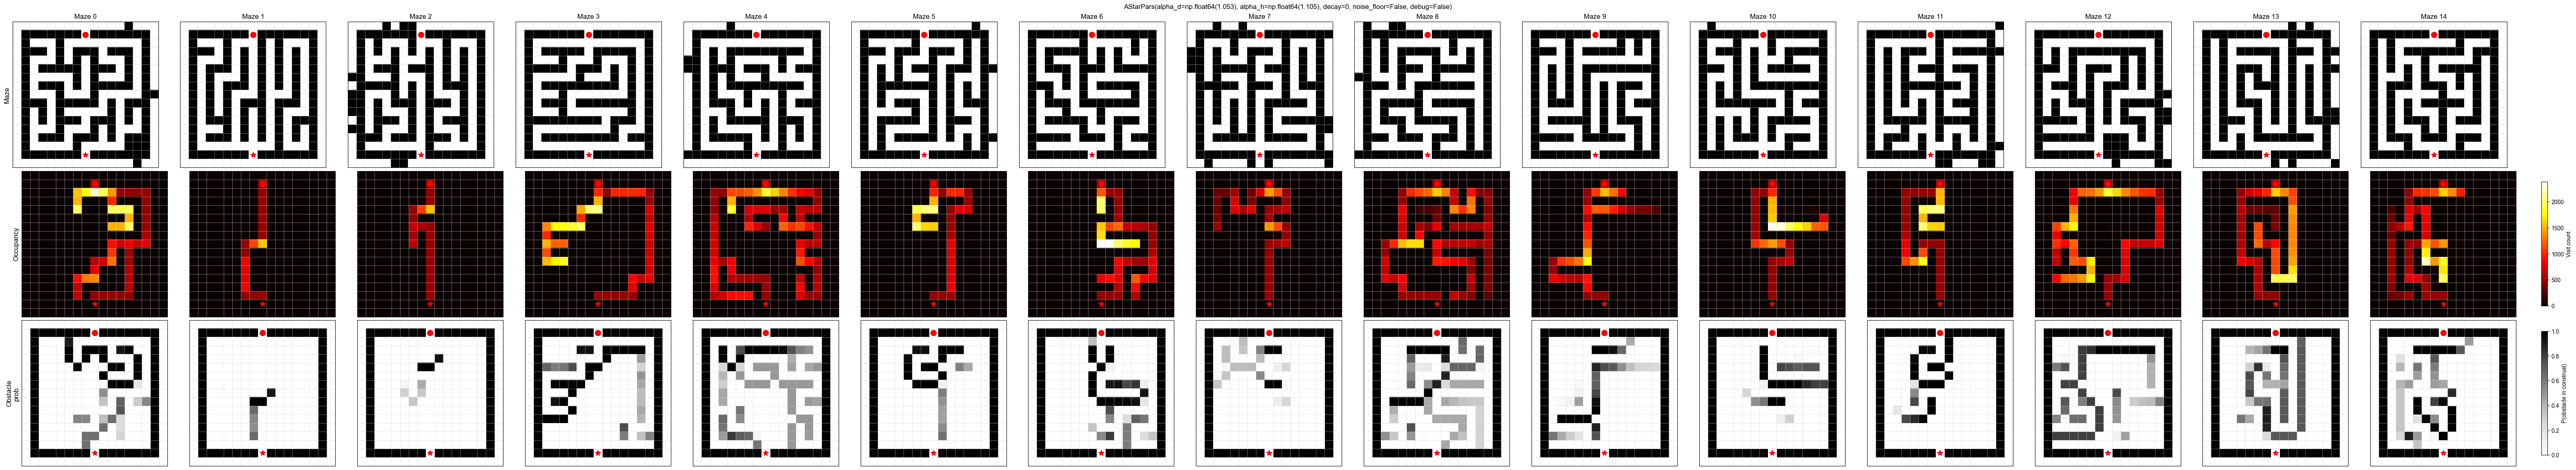

In [4]:
# Visualize one saved file (corresponding to one (alpha_d, alpha_h) combination)
n_mazes = 15
figsize_per_maze=(4.2, 3.8)
shared_colorbars = True
binary_per_rollout=False


with open(os.path.join("model_preds","jit","jit_param_sim_sharedconstr_"+str(108)+".pkl"), 'rb') as file:
    results_all = pickle.load(file)
results = results_all["results"]
alpha_d = results_all["alpha_d"]
alpha_h = results_all["alpha_h"]
decay = results_all["decay"]
print(alpha_d, alpha_h)

maze_idx = 10
results[maze_idx]["occ"]

# Figure
pars = jit.AStarPars(np.round(alpha_d,3), np.round(alpha_h,3), decay, False)
if shared_colorbars:
    occ_vmax = max(np.max(res["occ"]) for res in results) if results else 1
    prob_vmax = max(np.nanmax(res["prob_map"]) for res in results) if results else 1
else:
    occ_vmax = None
    prob_vmax = None
        
fig, ax = plt.subplots(
    3,
    n_mazes,
    figsize=(figsize_per_maze[0] * n_mazes, figsize_per_maze[1] * 3),
    constrained_layout=True
)

if n_mazes == 1:
    ax = np.array(ax).reshape(3, 1)

occ_last = None
prob_last = None

for col_idx, res in enumerate(results):
    maze_arr = res["maze_arr"]
    occ = res["occ"]
    prob_map = res["prob_map"]
    maze_shape = maze_arr.shape

    # -------------------------
    # Row 1: raw maze
    # -------------------------
    ax0 = ax[0, col_idx]
    maze_bg = build_original_maze_bg(maze_arr)
    ax0.imshow(maze_bg, cmap="gray", origin="upper", interpolation="nearest")
    ax0.set_title(f"Maze {res['maze_idx']}")

    sr, sc = start_goal_pos[0]
    gr, gc = start_goal_pos[1]
    ax0.plot(sr, sc, 'ro', markersize=10)
    ax0.plot(gr, gc, 'r*', markersize=10)

    ax0.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
    ax0.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
    ax0.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
    ax0.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

    if col_idx == 0:
        ax0.set_ylabel("Maze", fontsize=12)

    # -------------------------
    # Row 2: occupancy heatmap
    # -------------------------
    ax1 = ax[1, col_idx]
    if shared_colorbars:
        occ_last = ax1.imshow(
            occ, cmap="hot", origin="upper", interpolation="nearest",
            vmin=0, vmax=occ_vmax
        )
    else:
        occ_last = ax1.imshow(
            occ, cmap="hot", origin="upper", interpolation="nearest"
        )

    ax1.plot(sr, sc, 'ro', markersize=10)
    ax1.plot(gr, gc, 'r*', markersize=10)

    ax1.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
    ax1.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
    ax1.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
    ax1.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

    if col_idx == 0:
        ax1.set_ylabel("Occupancy", fontsize=12)

    if not shared_colorbars:
        cbar = fig.colorbar(occ_last, ax=ax1, shrink=0.8, pad=0.02)
        cbar.set_label("Visit count" if not binary_per_rollout else "Visited in rollout")

    # -------------------------
    # Row 3: obstacle probs
    # -------------------------
    ax2 = ax[2, col_idx]

    # white background under NaNs
    bg = np.ones(maze_shape, dtype=float)
    ax2.imshow(bg, cmap="gray", origin="upper", interpolation="nearest", vmin=0, vmax=1)

    if shared_colorbars:
        prob_last = ax2.imshow(
            prob_map, cmap="Greys", origin="upper", interpolation="nearest",
            vmin=0, vmax=prob_vmax
        )
    else:
        prob_last = ax2.imshow(
            prob_map, cmap="Greys", origin="upper", interpolation="nearest"
        )

    ax2.plot(sr, sc, 'ro', markersize=10)
    ax2.plot(gr, gc, 'r*', markersize=10)

    ax2.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
    ax2.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
    ax2.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
    ax2.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

    if col_idx == 0:
        ax2.set_ylabel("Obstacle\nprob.", fontsize=12)

    if not shared_colorbars:
        cbar = fig.colorbar(prob_last, ax=ax2, shrink=0.8, pad=0.02)
        cbar.set_label("P(obstacle in construal)")

# Shared colorbars
if shared_colorbars and n_mazes > 0:
    cbar1 = fig.colorbar(occ_last, ax=ax[1, :], shrink=0.85, pad=0.01)
    cbar1.set_label("Visit count" if not binary_per_rollout else "Visited in rollout")

    cbar2 = fig.colorbar(prob_last, ax=ax[2, :], shrink=0.85, pad=0.01)
    cbar2.set_label("P(obstacle in construal)")
    
fig.suptitle(pars)
# plt.savefig(os.path.join(figpath,"jit_sim_example_allmazes"), dpi=300, bbox_inches="tight")
plt.show()

# Frequency of rim location visitation, across 20x20 param value grid

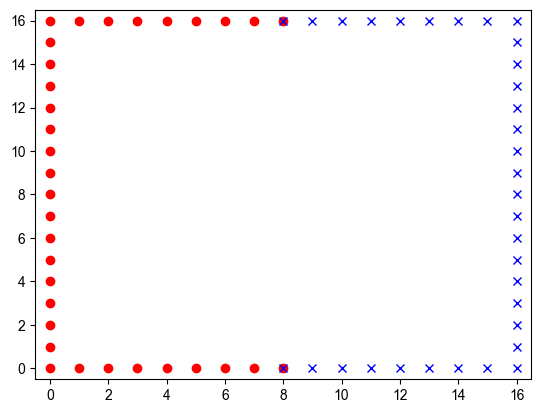

In [5]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Basic helpers
# =========================================================
def load_single_result(filepath):
    with open(filepath, "rb") as file:
        return pickle.load(file)


def compute_rim_mask(shape, rim_rows=(0, 16), rim_cols=(0, 16)):
    mask = np.zeros(shape, dtype=bool)

    for r in rim_rows:
        if 0 <= r < shape[0]:
            mask[r, :] = True

    for c in rim_cols:
        if 0 <= c < shape[1]:
            mask[:, c] = True

    return mask


def rim_visit_proportion_from_occ(occ, rim_mask):
    total_visits = np.sum(occ)
    if total_visits == 0:
        return np.nan
    return np.sum(occ[rim_mask]) / total_visits


# =========================================================
# Path-based helpers
# Note: these operate directly on path tuples as stored in
# results[maze_idx]["paths"], i.e. in the same coordinate
# system like (8,0), (7,0), ..., (8,14).
# =========================================================
def build_rim_coordinate_set(max_coord=16):
    """
    Coordinates are treated as (x, y).
    Rim means x in {0,16} or y in {0,16}.
    """
    return {
        (x, y)
        for x in range(max_coord + 1)
        for y in range(max_coord + 1)
        if (x == 0 or x == max_coord or y == 0 or y == max_coord)
    }


def build_two_full_rim_routes(max_coord=16):
    """
    Construct the two canonical full rim routes described by you.

    Entry point on rim:  (8, 0)
    Exit point near goal: (8, 14)

    Route A:
      (8,0) -> left along top edge to (0,0)
             -> down left edge to (0,16)
             -> right along bottom edge to (8,16)

    Route B:
      (8,0) -> right along top edge to (16,0)
             -> down right edge to (16,16)
             -> left along bottom edge to (8,16)

    Returns
    -------
    route_left, route_right : sets of (x, y)
    """
    # Left route
    route_left = set()

    # top edge: (8,0) -> (0,0)
    for x in range(0, 9):
        route_left.add((x, 0))

    # left edge: (0,0) -> (0,16)
    for y in range(0, max_coord + 1):
        route_left.add((0, y))

    # bottom edge: (0,16) -> (8,16)
    for x in range(0, 9):
        route_left.add((x, max_coord))

    # Right route
    route_right = set()

    # top edge: (8,0) -> (16,0)
    for x in range(8, max_coord + 1):
        route_right.add((x, 0))

    # right edge: (16,0) -> (16,16)
    for y in range(0, max_coord + 1):
        route_right.add((max_coord, y))

    # bottom edge: (16,16) -> (8,16)
    for x in range(8, max_coord + 1):
        route_right.add((x, max_coord))

    return route_left, route_right


def label_full_rim_route(path, route_left, route_right):
    """
    Label 1 iff the path contains all coordinates of either full rim route.
    """
    path_set = set(path)
    return int(route_left.issubset(path_set) or route_right.issubset(path_set))


def label_any_rim_visit(path, rim_coords):
    """
    Label 1 iff the path visits any rim coordinate.
    """
    path_set = set(path)
    return int(len(path_set & rim_coords) > 0)


def label_all_rim_only(path, rim_coords, start):
    """
    Label 1 iff every visited coordinate is on the rim.
    """
    path_set = set(path)
    path_set.remove(start) # starting point is not on rim, but must be traversed
    if len(path_set) == 0:
        return 0
    return int(path_set.issubset(rim_coords))


# =========================================================
# Main function
# =========================================================
def build_jit_param_4panel(
    model_preds_dir,
    alpha_ds,
    alpha_hs,
    filename_prefix="jit_param_sim_",
    maze_idx=None,
    aggregate_across_mazes=True,
    rim_rows=(0, 16),
    rim_cols=(0, 16),
    max_coord=16,
    figsize=(20, 5),
    start_goal_pos = start_goal_pos,
    show_plot=True,
):
    """
    Build 4 parameter-grid heatmaps:
      1) proportion of visits on rim, from occ
      2) proportion of simulations containing a full rim route: given that JIT is bumping and restarting from the step just before the bump happened, 
                                                                 it may be too strict to disallow any attempts to go through the interior. Hence this.
      3) proportion of simulations visiting any rim square: this is the most lenient definition.
      4) proportion of simulations staying entirely on rim: this is assuming that participants don't do visual saccades outside of WASD in our task.

    Parameters
    ----------
    model_preds_dir : str
    alpha_ds : 1D array
    alpha_hs : 1D array
    filename_prefix : str
    maze_idx : int or None
        Used only if aggregate_across_mazes=False
    aggregate_across_mazes : bool
        If True, average path labels over all mazes and all sims.
        If False, use only one maze specified by maze_idx.
    rim_rows, rim_cols : tuple
        For occ-based rim mask.
    max_coord : int
        Outer coordinate value for paths, default 16.
    """

    n_d = len(alpha_ds)
    n_h = len(alpha_hs)

    grid_occ_rim = np.full((n_d, n_h), np.nan, dtype=float)
    grid_full_rim_route = np.full((n_d, n_h), np.nan, dtype=float)
    grid_any_rim = np.full((n_d, n_h), np.nan, dtype=float)
    grid_all_rim_only = np.full((n_d, n_h), np.nan, dtype=float)

    rim_coords = build_rim_coordinate_set(max_coord=max_coord)
    route_left, route_right = build_two_full_rim_routes(max_coord=max_coord)

    n_files = n_d * n_h

    for file_idx in range(n_files):
        filepath = os.path.join(model_preds_dir, f"{filename_prefix}{file_idx}.pkl")
        if not os.path.exists(filepath):
            print(f"Missing file: {filepath}")
            continue

        results_all = load_single_result(filepath)
        results = results_all["results"]
        alpha_d = results_all["alpha_d"]
        alpha_h = results_all["alpha_h"]

        # robust mapping to grid indices using actual parameter values
        row_idx = int(np.argmin(np.abs(alpha_ds - alpha_d)))
        col_idx = int(np.argmin(np.abs(alpha_hs - alpha_h)))

        # -------------------------
        # 1) occ-based rim proportion
        # -------------------------
        if aggregate_across_mazes:
            occ_sum = None
            for res in results:
                occ = np.asarray(res["occ"], dtype=float)
                if occ_sum is None:
                    occ_sum = np.zeros_like(occ, dtype=float)
                occ_sum += occ
        else:
            if maze_idx is None:
                raise ValueError("maze_idx must be provided if aggregate_across_mazes=False")
            occ_sum = np.asarray(results[maze_idx]["occ"], dtype=float)

        rim_mask = compute_rim_mask(occ_sum.shape, rim_rows=rim_rows, rim_cols=rim_cols)
        grid_occ_rim[row_idx, col_idx] = rim_visit_proportion_from_occ(occ_sum, rim_mask)

        # -------------------------
        # 2)-4) path-based labels
        # -------------------------
        if aggregate_across_mazes:
            path_list = []
            for res in results:
                path_list.extend(res["paths"])
        else:
            path_list = results[maze_idx]["paths"]

        labels_full_rim_route = [label_full_rim_route(p, route_left, route_right) for p in path_list]
        labels_any_rim = [label_any_rim_visit(p, rim_coords) for p in path_list]
        labels_all_rim_only = [label_all_rim_only(p, rim_coords, start_goal_pos[0]) for p in path_list]

        grid_full_rim_route[row_idx, col_idx] = np.mean(labels_full_rim_route) if len(labels_full_rim_route) > 0 else np.nan
        grid_any_rim[row_idx, col_idx] = np.mean(labels_any_rim) if len(labels_any_rim) > 0 else np.nan
        grid_all_rim_only[row_idx, col_idx] = np.mean(labels_all_rim_only) if len(labels_all_rim_only) > 0 else np.nan

    # -------------------------
    # Plot
    # -------------------------
    if show_plot:
        X, Y = np.meshgrid(alpha_hs, alpha_ds)
        fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=True)
    
        grids = [
            grid_occ_rim,
            grid_full_rim_route,
            grid_any_rim,
            grid_all_rim_only,
        ]
    
        titles = [
            "% of all visits that are on either rim",
            "P(path visits all squares along either rim)",
            "P(path visits any rim square)",
            "P(path only visits rim square)",
        ]
    
        im = None
    
        panel_letters = ["A", "B", "C", "D"]
        
        for panel_idx, (ax, grid, title) in enumerate(zip(axes, grids, titles)):
            im = ax.imshow(
                grid,
                origin="lower",
                interpolation="nearest",
                aspect="auto",
                extent=[
                    alpha_hs.min(), alpha_hs.max(),
                    alpha_ds.min(), alpha_ds.max()
                ],
                cmap="Grays",
                vmin=0,
                vmax=1
            )
        
            CS = ax.contour(X, Y, grid, linewidths=0.5)
            ax.clabel(CS, inline=True, fontsize=8, fmt="%1.1f")
        
            ax.text(
                -0.12, 1.1,
                panel_letters[panel_idx],
                transform=ax.transAxes,
                fontsize=20,
                fontweight="bold",
                va="top",
                ha="left",
                color="black"
            )
        
            ax.set_title(title, fontsize=14)
            ax.set_xlabel(r"$\alpha_h$")
            ax.set_ylabel(r"$\alpha_d$")
            ax.set_xticks([-1,0,1,2,3,4])
            ax.set_yticks([0,1,2,3,4])
            #plt.colorbar(im, ax=ax, shrink=0.9, pad=0.02)
    
        # One shared colorbar for all four panels
        cbar = fig.colorbar(
            im,
            ax=axes,
            shrink=1,
            pad=0.02,
            location="right"
        )
        cbar.set_label("Proportion of simulations", fontsize=14)
        cbar.ax.tick_params(labelsize=12)
    
    
        # fig.suptitle(
        #     rf"{len(res['paths'])} simulations per ($\alpha_d$, $\alpha_h$) combination"
        # )
    return {
        "grid_occ_rim": grid_occ_rim,
        "grid_full_rim_route": grid_full_rim_route,
        "grid_any_rim": grid_any_rim,
        "grid_all_rim_only": grid_all_rim_only,
    }


# Check if the rim path coordinate function works as intended
rims = build_two_full_rim_routes(max_coord=16)
x,y = zip(*list(rims[0]))
plt.plot(x,y,"ro")
x,y = zip(*list(rims[1]))
plt.plot(x,y,"bx")
plt.xlim(-0.5,16.5)
plt.ylim(-0.5,16.5)
plt.show()

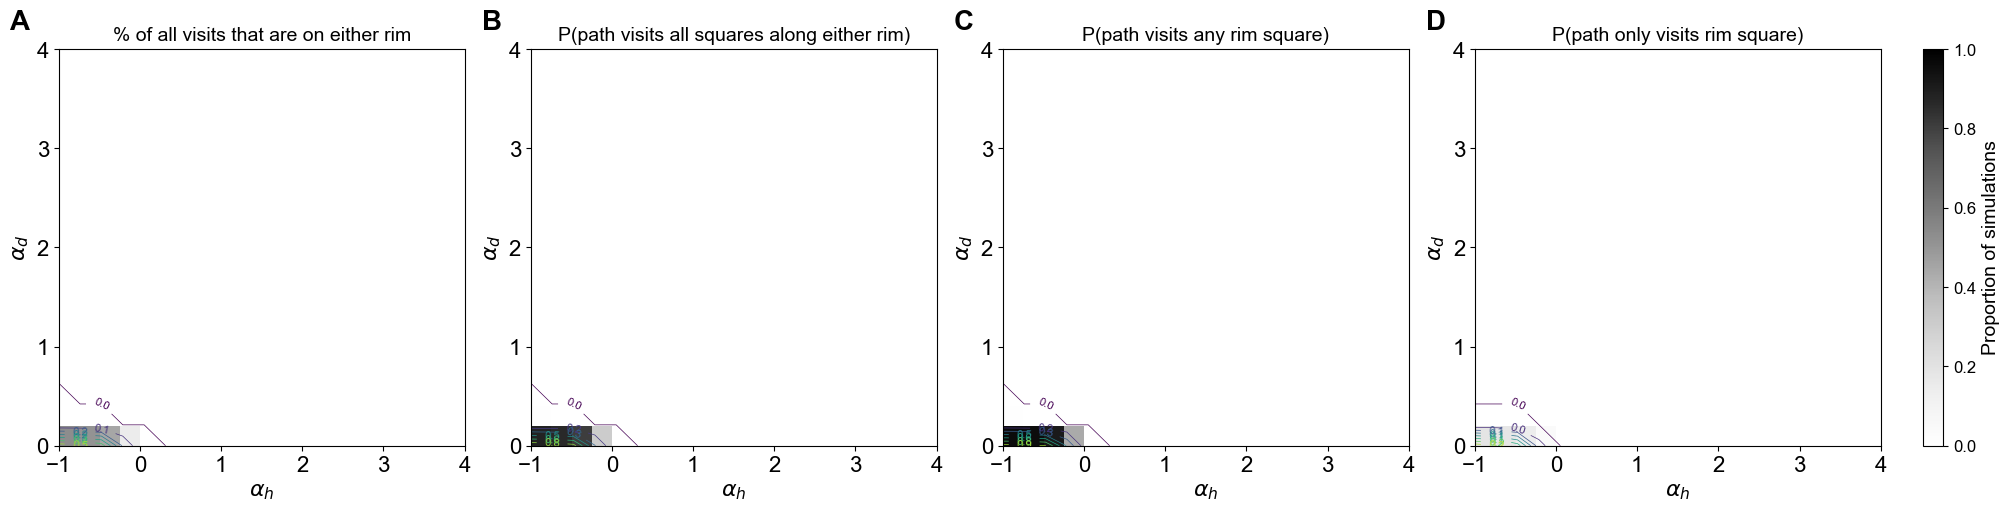

In [6]:
n_param_grid = 20
alpha_ds = np.linspace(0.0, 4, n_param_grid)
alpha_hs = np.linspace(-1.0, 4, n_param_grid)
plt.rcParams.update({'font.size': 16})

# This set of model fits assume that agents initialize by representing all outer walls.
out = build_jit_param_4panel(
    model_preds_dir="model_preds/jit",
    alpha_ds=alpha_ds,
    alpha_hs=alpha_hs,
    filename_prefix="jit_param_sim_sharedconstr_",
    aggregate_across_mazes=True,   # average over all mazes and all sims
    rim_rows=(0, 16),
    rim_cols=(0, 16),
    max_coord=16,
    figsize=(20, 5),
    start_goal_pos = start_goal_pos,
    show_plot=True,
)

# plt.savefig(os.path.join(figpath, "exp1_jit_sim_allparamcombs_sharedconstr.png"), dpi=300)
plt.savefig(os.path.join(figpath, "exp1_jit_sim_allparamcombs_sharedconstr.pdf"), bbox_inches="tight")
plt.show()

In [7]:
# Same as above, but print proportions in text
def rim_grid_to_df(alpha_ds, alpha_hs):
    rows = []
    alpha_h_grid, alpha_d_grid = np.meshgrid(alpha_hs, alpha_ds)
    n_r, n_c = alpha_d_grid.shape
    for i in range(n_r):
        for j in range(n_c):
            rows.append({
                "alpha_d_idx": i,
                "alpha_h_idx": j,
                "alpha_d": alpha_d_grid[i, j],
                "alpha_h": alpha_h_grid[i, j],
                
                "grid_occ_rim": out["grid_occ_rim"][i,j],
                "grid_full_rim_route": out["grid_full_rim_route"][i,j],
                "grid_any_rim": out["grid_any_rim"][i,j],
                "grid_all_rim_only": out["grid_all_rim_only"][i,j],
            })
    return pd.DataFrame(rows)

df_rim = rim_grid_to_df(alpha_ds, alpha_hs)
df_rim.to_csv(os.path.join("model_preds","jit","exp1_jit_sim_allparamcombs.csv"))
print(df_rim)

     alpha_d_idx  alpha_h_idx  alpha_d   alpha_h  grid_occ_rim  \
0              0            0      0.0 -1.000000      0.527683   
1              0            1      0.0 -0.736842      0.508223   
2              0            2      0.0 -0.473684      0.446085   
3              0            3      0.0 -0.210526      0.147689   
4              0            4      0.0  0.052632      0.000069   
..           ...          ...      ...       ...           ...   
395           19           15      4.0  2.947368      0.000000   
396           19           16      4.0  3.210526      0.000000   
397           19           17      4.0  3.473684      0.000000   
398           19           18      4.0  3.736842      0.000000   
399           19           19      4.0  4.000000      0.000000   

     grid_full_rim_route  grid_any_rim  grid_all_rim_only  
0               0.881067      0.959867           0.191333  
1               0.861467      0.951467           0.177467  
2               0.805067   

In [10]:
# Sanity check: did all paths reach the goal? Yes!
def path_is_success(path):
    '''For JIT, need to see if goal (8,15) has been reached by each path simulation.'''
    path_set = set(path)
    if(((8,16) in path_set) or ((8,14) in path_set)):
        return True
    return False


n_files = 400
n_mazes = 15
n_sims = 500
model_preds_dir = "model_preds/jit"
filename_prefix="jit_param_sim_sharedconstr_"
path_success_count = np.zeros((n_files,))
for file_idx in range(n_files):
    filepath = os.path.join(model_preds_dir, filename_prefix + str(file_idx)+".pkl")
    if not os.path.exists(filepath):
        print(f"Missing file: {filepath}")
        continue

    results_all = load_single_result(filepath)
    results = results_all["results"]
    
    path_success_count_loc = 0
    for result in results:
        paths = result["paths"]
        for path in paths:
            path_success_count_loc = path_success_count_loc + path_is_success(path)
    path_success_count[file_idx] = path_success_count_loc
            
        
print(path_success_count/(n_sims*n_mazes))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.